# Practice: Physics-informed FNO (PINO) for 2D Navier--Stokes

This notebook is a **PINO-style** practice notebook.

Here, PINO means:

$$
\text{Fourier Neural Operator} + \text{PDE residual loss}.
$$

The model learns the solution operator for the 2D incompressible Navier--Stokes equation in vorticity form:

$$
\mathcal{G}: \omega_0(x,y) \mapsto \{\omega(t_j,x,y)\}_{j=1}^{N_t}.
$$

Unlike pure FNO, we do not train only with data.  
We also add a physics loss from the PDE residual.

---

## Main idea

The PDE is

$$
\partial_t \omega + u\cdot \nabla \omega = \nu \Delta \omega.
$$

So the residual is

$$
r = \partial_t \omega + u\cdot \nabla \omega - \nu \Delta \omega.
$$

The PINO loss is

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{data}}
+
\beta \mathcal{L}_{\mathrm{PDE}}.
$$

where

$$
\mathcal{L}_{\mathrm{data}}
=
\|\omega_\theta - \omega_{\mathrm{data}}\|^2
$$

and

$$
\mathcal{L}_{\mathrm{PDE}}
=
\|r_\theta\|^2.
$$

---

## Why we predict a trajectory

If the model predicts only \(\omega(T,x,y)\), it is hard to compute \(\partial_t \omega\).

So in this notebook, the model predicts a short trajectory:

$$
\omega_0(x,y)
\mapsto
\omega(t_1,x,y),\omega(t_2,x,y),\dots,\omega(t_M,x,y).
$$

Then we approximate

$$
\partial_t \omega(t_j,x,y)
\approx
\frac{\omega(t_{j+1},x,y)-\omega(t_j,x,y)}{\Delta t}.
$$

## 1. PDE setting

We consider the 2D Navier--Stokes equation in vorticity form:

$$
\partial_t \omega + u \cdot \nabla \omega = \nu \Delta \omega.
$$

The velocity field \(u=(u_1,u_2)\) is recovered from the stream function \(\psi\):

$$
u_1 = \partial_y \psi,
\qquad
u_2 = -\partial_x \psi,
$$

where

$$
-\Delta \psi = \omega.
$$

We use periodic boundary conditions on \([0,1]^2\).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## 2. Basic settings

The default values are small so that the notebook is suitable for lecture practice.

For better results, increase:

```python
n_train
epochs
n_grid
width
```

In [2]:
# -----------------------------
# Problem setting
# -----------------------------
n_grid = 32

n_train = 60
n_test = 20

nu = 1e-2

T = 1.0
n_frames = 5          # including t=0
dt_save = T / (n_frames - 1)

dt_solver = 0.005     # internal solver step

print("dt_save:", dt_save)

dt_save: 0.25


## 3. Generate random initial vorticity

Each sample is a different initial condition:

$$
\omega_0^{(i)}(x,y).
$$

This is important for operator learning because we want one model to handle many different initial conditions.

In [3]:
def generate_random_vorticity(batch_size, n_grid, max_mode=4):
    """
    Generate smooth random initial vorticity fields.

    Output:
        w0 shape = (batch_size, n_grid, n_grid)
    """
    x = torch.linspace(0, 1, n_grid, device=device)
    y = torch.linspace(0, 1, n_grid, device=device)

    X, Y = torch.meshgrid(x, y, indexing="ij")

    w = torch.zeros(batch_size, n_grid, n_grid, device=device)

    for kx in range(1, max_mode + 1):
        for ky in range(1, max_mode + 1):
            scale = 1.0 / (kx**2 + ky**2)

            a = scale * torch.randn(batch_size, 1, 1, device=device)
            b = scale * torch.randn(batch_size, 1, 1, device=device)

            phase = 2 * np.pi * (kx * X + ky * Y)

            w += a * torch.sin(phase)
            w += b * torch.cos(phase)

    # Normalize each sample.
    w = w / (w.std(dim=(1, 2), keepdim=True) + 1e-6)

    return w

## 4. Pseudo-spectral solver for data generation

This solver is used only to generate training data.

The model will see pairs:

$$
\omega_0^{(i)}(x,y)
\quad\longrightarrow\quad
\{\omega^{(i)}(t_j,x,y)\}_{j=1}^{M}.
$$

In [4]:
def make_wavenumbers(n_grid, device):
    """
    Fourier wavenumbers for rfft2.
    """
    kx = 2 * np.pi * torch.fft.fftfreq(n_grid, d=1.0 / n_grid).to(device)
    ky = 2 * np.pi * torch.fft.rfftfreq(n_grid, d=1.0 / n_grid).to(device)

    kx = kx[:, None]
    ky = ky[None, :]

    K2 = kx**2 + ky**2
    K2[0, 0] = 1.0

    return kx, ky, K2


def navier_stokes_trajectory_solver(w0, nu=1e-3, T=0.5, dt_solver=0.005, n_frames=6):
    """
    Generate a trajectory for 2D Navier--Stokes in vorticity form.

    Input:
        w0: shape (batch, n_grid, n_grid)

    Output:
        traj: shape (batch, n_frames, n_grid, n_grid)
              traj[:,0] is the initial condition.
    """
    batch_size, n_grid, _ = w0.shape

    steps_total = int(round(T / dt_solver))
    dt_solver = T / steps_total

    save_every = steps_total // (n_frames - 1)

    kx, ky, K2 = make_wavenumbers(n_grid, w0.device)

    # 2/3 de-aliasing mask
    kx_int = torch.fft.fftfreq(n_grid, d=1.0 / n_grid).to(w0.device)[:, None]
    ky_int = torch.fft.rfftfreq(n_grid, d=1.0 / n_grid).to(w0.device)[None, :]
    cutoff = n_grid / 3
    dealias = ((kx_int.abs() <= cutoff) & (ky_int.abs() <= cutoff)).float()

    w_hat = torch.fft.rfft2(w0, dim=(-2, -1))

    traj = [w0]

    for step in range(1, steps_total + 1):
        # Stream function: -Delta psi = omega
        psi_hat = -w_hat / K2
        psi_hat[:, 0, 0] = 0.0

        # Velocity: u1 = psi_y, u2 = -psi_x
        u1_hat = 1j * ky * psi_hat
        u2_hat = -1j * kx * psi_hat

        # Vorticity gradients
        wx_hat = 1j * kx * w_hat
        wy_hat = 1j * ky * w_hat

        u1 = torch.fft.irfft2(u1_hat, s=(n_grid, n_grid), dim=(-2, -1))
        u2 = torch.fft.irfft2(u2_hat, s=(n_grid, n_grid), dim=(-2, -1))

        wx = torch.fft.irfft2(wx_hat, s=(n_grid, n_grid), dim=(-2, -1))
        wy = torch.fft.irfft2(wy_hat, s=(n_grid, n_grid), dim=(-2, -1))

        # Nonlinear advection
        nonlinear = u1 * wx + u2 * wy
        nonlinear_hat = torch.fft.rfft2(nonlinear, dim=(-2, -1))
        nonlinear_hat = nonlinear_hat * dealias

        # Semi-implicit Euler
        w_hat = (w_hat - dt_solver * nonlinear_hat) / (1.0 + dt_solver * nu * K2)

        if step % save_every == 0 and len(traj) < n_frames:
            w = torch.fft.irfft2(w_hat, s=(n_grid, n_grid), dim=(-2, -1))
            traj.append(w)

    traj = torch.stack(traj, dim=1)

    return traj

## 5. Prepare training and test data

Input:

$$
\omega_0(x,y)
$$

Output:

$$
\omega(t_1,x,y),\dots,\omega(t_M,x,y)
$$

We exclude \(t=0\) from the target because it is already given as the input.

In [5]:
# Initial conditions
w0_train_raw = generate_random_vorticity(n_train, n_grid)
w0_test_raw = generate_random_vorticity(n_test, n_grid)

# Generate trajectories
with torch.no_grad():
    traj_train = navier_stokes_trajectory_solver(
        w0_train_raw, nu=nu, T=T, dt_solver=dt_solver, n_frames=n_frames
    )
    traj_test = navier_stokes_trajectory_solver(
        w0_test_raw, nu=nu, T=T, dt_solver=dt_solver, n_frames=n_frames
    )

# Input: omega_0
# Shape: (batch, n_grid, n_grid, 1)
w0_train = traj_train[:, 0, :, :, None]
w0_test = traj_test[:, 0, :, :, None]

# Target: future trajectory excluding t=0
# Shape: (batch, n_grid, n_grid, n_frames-1)
y_train = traj_train[:, 1:, :, :].permute(0, 2, 3, 1)
y_test = traj_test[:, 1:, :, :].permute(0, 2, 3, 1)

print("w0_train:", w0_train.shape)
print("y_train:", y_train.shape)
print("w0_test:", w0_test.shape)
print("y_test:", y_test.shape)

w0_train: torch.Size([60, 32, 32, 1])
y_train: torch.Size([60, 32, 32, 4])
w0_test: torch.Size([20, 32, 32, 1])
y_test: torch.Size([20, 32, 32, 4])


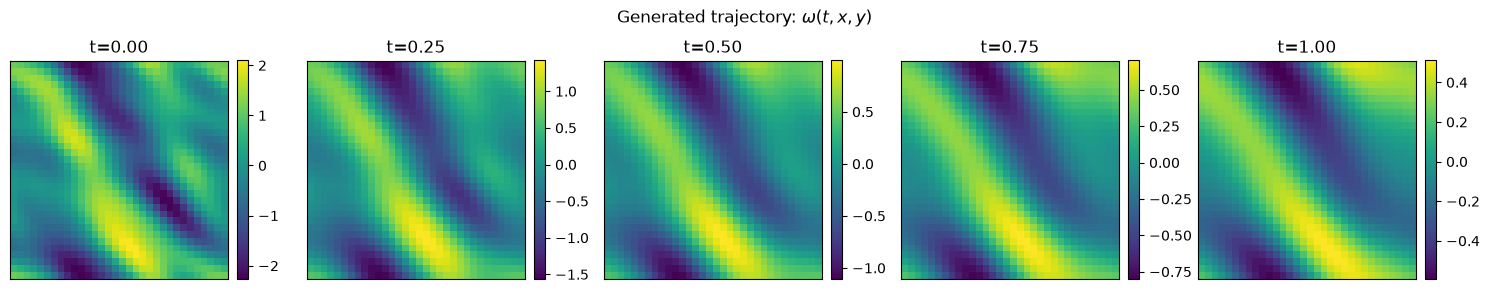

In [6]:
# Visualize one generated trajectory
sample_id = 0

plt.figure(figsize=(3 * n_frames, 3))

for j in range(n_frames):
    plt.subplot(1, n_frames, j + 1)
    plt.imshow(traj_train[sample_id, j].detach().cpu(), origin="lower")
    plt.title(f"t={j * dt_save:.2f}")
    plt.xticks([])
    plt.yticks([])
    plt.colorbar(fraction=0.046, pad=0.04)

plt.suptitle(r"Generated trajectory: $\omega(t,x,y)$")
plt.tight_layout()
plt.show()

## 6. 2D Fourier Neural Operator

The model is an FNO that maps

$$
\omega_0(x,y)
\mapsto
\omega(t_1,x,y),\dots,\omega(t_M,x,y).
$$

The output channel dimension corresponds to time frames.

In [7]:
class SpectralConv2D(nn.Module):
    """
    2D spectral convolution layer.
    """
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        scale = 1.0 / (in_channels * out_channels)

        self.weights1 = nn.Parameter(
            scale * torch.randn(
                in_channels, out_channels, modes1, modes2, dtype=torch.cfloat
            )
        )

        self.weights2 = nn.Parameter(
            scale * torch.randn(
                in_channels, out_channels, modes1, modes2, dtype=torch.cfloat
            )
        )

    def complex_multiply_2d(self, x, weights):
        return torch.einsum("bixy,ioxy->boxy", x, weights)

    def forward(self, x):
        batch_size, channels, nx, ny = x.shape

        x_ft = torch.fft.rfft2(x, dim=(-2, -1))

        out_ft = torch.zeros(
            batch_size,
            self.out_channels,
            nx,
            ny // 2 + 1,
            device=x.device,
            dtype=torch.cfloat
        )

        out_ft[:, :, :self.modes1, :self.modes2] = self.complex_multiply_2d(
            x_ft[:, :, :self.modes1, :self.modes2],
            self.weights1
        )

        out_ft[:, :, -self.modes1:, :self.modes2] = self.complex_multiply_2d(
            x_ft[:, :, -self.modes1:, :self.modes2],
            self.weights2
        )

        x = torch.fft.irfft2(out_ft, s=(nx, ny), dim=(-2, -1))

        return x

In [8]:
class FNO2D_Trajectory(nn.Module):
    def __init__(self, modes1=8, modes2=8, width=32, out_frames=5):
        super().__init__()

        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.out_frames = out_frames

        # Input channels: omega_0(x,y), x, y
        self.lift = nn.Linear(3, width)

        self.conv0 = SpectralConv2D(width, width, modes1, modes2)
        self.conv1 = SpectralConv2D(width, width, modes1, modes2)
        self.conv2 = SpectralConv2D(width, width, modes1, modes2)
        self.conv3 = SpectralConv2D(width, width, modes1, modes2)

        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)
        self.w3 = nn.Conv2d(width, width, 1)

        self.project = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Linear(64, out_frames)
        )

    def get_grid(self, batch_size, nx, ny, device):
        gridx = torch.linspace(0, 1, nx, device=device)
        gridy = torch.linspace(0, 1, ny, device=device)

        gridx = gridx.reshape(1, nx, 1, 1).repeat(batch_size, 1, ny, 1)
        gridy = gridy.reshape(1, 1, ny, 1).repeat(batch_size, nx, 1, 1)

        return torch.cat([gridx, gridy], dim=-1)

    def forward(self, w0):
        """
        Input:
            w0: shape (batch, nx, ny, 1)

        Output:
            pred future trajectory:
            shape (batch, nx, ny, out_frames)
        """
        batch_size, nx, ny, _ = w0.shape

        grid = self.get_grid(batch_size, nx, ny, w0.device)

        # Lifting
        x = torch.cat([w0, grid], dim=-1)
        x = self.lift(x)

        # FNO layers
        x = x.permute(0, 3, 1, 2)

        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = F.gelu(self.conv3(x) + self.w3(x))

        # Projection
        x = x.permute(0, 2, 3, 1)
        out = self.project(x)

        return out

## 7. PDE residual loss

We compute the Navier--Stokes residual from the predicted trajectory.

The predicted full trajectory is

$$
\omega_\theta(t_0),\omega_\theta(t_1),\dots,\omega_\theta(t_M),
$$

where \(\omega_\theta(t_0)=\omega_0\) is the input.

The time derivative is approximated by

$$
\partial_t \omega_\theta(t_j)
\approx
\frac{\omega_\theta(t_{j+1})-\omega_\theta(t_j)}{\Delta t}.
$$

The spatial derivatives are computed by Fourier transform.

In [9]:
def ns_rhs_vorticity(w, nu=1e-3):
    """
    Compute RHS of vorticity Navier--Stokes:

        w_t = - u · grad(w) + nu Delta w

    Input:
        w shape = (batch, nx, ny)

    Output:
        rhs shape = (batch, nx, ny)
    """
    batch_size, nx, ny = w.shape

    kx, ky, K2 = make_wavenumbers(nx, w.device)

    w_hat = torch.fft.rfft2(w, dim=(-2, -1))

    # Stream function: -Delta psi = w
    psi_hat = -w_hat / K2
    psi_hat[:, 0, 0] = 0.0

    # Velocity
    u1_hat = 1j * ky * psi_hat
    u2_hat = -1j * kx * psi_hat

    # Gradients
    wx_hat = 1j * kx * w_hat
    wy_hat = 1j * ky * w_hat

    # Laplacian
    lap_w_hat = -K2 * w_hat

    u1 = torch.fft.irfft2(u1_hat, s=(nx, ny), dim=(-2, -1))
    u2 = torch.fft.irfft2(u2_hat, s=(nx, ny), dim=(-2, -1))

    wx = torch.fft.irfft2(wx_hat, s=(nx, ny), dim=(-2, -1))
    wy = torch.fft.irfft2(wy_hat, s=(nx, ny), dim=(-2, -1))

    lap_w = torch.fft.irfft2(lap_w_hat, s=(nx, ny), dim=(-2, -1))

    nonlinear = u1 * wx + u2 * wy

    rhs = -nonlinear + nu * lap_w

    return rhs


def pino_pde_loss(w0, pred_future, nu=1e-3, dt_save=0.1):
    """
    PINO PDE loss for predicted trajectory.

    Input:
        w0:          shape (batch, nx, ny, 1)
        pred_future: shape (batch, nx, ny, out_frames)

    We form the full trajectory:
        [w0, pred_future_1, ..., pred_future_M]

    Then residual:
        (w_{j+1} - w_j) / dt - RHS(w_j)
    """
    # Full trajectory: (batch, nx, ny, n_frames)
    full = torch.cat([w0, pred_future], dim=-1)

    # Convert to: (batch, n_frames, nx, ny)
    full = full.permute(0, 3, 1, 2)

    w_current = full[:, :-1]   # (batch, n_frames-1, nx, ny)
    w_next = full[:, 1:]       # (batch, n_frames-1, nx, ny)

    # Time derivative
    w_t = (w_next - w_current) / dt_save

    batch_size, nt, nx, ny = w_current.shape

    # Flatten time into batch dimension for RHS computation
    w_flat = w_current.reshape(batch_size * nt, nx, ny)

    rhs_flat = ns_rhs_vorticity(w_flat, nu=nu)
    rhs = rhs_flat.reshape(batch_size, nt, nx, ny)

    residual = w_t - rhs

    return torch.mean(residual**2)

## 8. Train PINO

The loss is

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{data}}
+
\beta \mathcal{L}_{\mathrm{PDE}}.
$$

Here,

$$
\mathcal{L}_{\mathrm{data}}
=
\|\omega_\theta-\omega_{\mathrm{data}}\|^2.
$$

and

$$
\mathcal{L}_{\mathrm{PDE}}
=
\|\partial_t\omega_\theta+u_\theta\cdot\nabla\omega_\theta-\nu\Delta\omega_\theta\|^2.
$$

In [10]:
def relative_l2_error(pred, true):
    """
    pred, true shape:
        (batch, nx, ny, out_frames)
    """
    pred = pred.reshape(pred.shape[0], -1)
    true = true.reshape(true.shape[0], -1)

    return torch.norm(pred - true, dim=1) / torch.norm(true, dim=1)


def train_pino(model, train_x, train_y, test_x, test_y,
               epochs=100, batch_size=10, beta=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    mse = nn.MSELoss()

    n_train = train_x.shape[0]

    train_data_history = []
    train_pde_history = []
    test_data_history = []
    test_rel_l2_history = []

    for epoch in range(epochs):
        model.train()

        perm = torch.randperm(n_train, device=device)

        total_data_loss = 0.0
        total_pde_loss = 0.0
        num_batches = 0

        for i in range(0, n_train, batch_size):
            idx = perm[i:i + batch_size]

            batch_x = train_x[idx]
            batch_y = train_y[idx]

            pred = model(batch_x)

            loss_data = mse(pred, batch_y)
            loss_pde = pino_pde_loss(batch_x, pred, nu=nu, dt_save=dt_save)

            loss = loss_data + beta * loss_pde

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_data_loss += loss_data.item()
            total_pde_loss += loss_pde.item()
            num_batches += 1

        train_data_loss = total_data_loss / num_batches
        train_pde_loss = total_pde_loss / num_batches

        model.eval()
        with torch.no_grad():
            test_pred = model(test_x)
            test_data_loss = mse(test_pred, test_y).item()
            test_rel_l2 = relative_l2_error(test_pred, test_y).mean().item()

        train_data_history.append(train_data_loss)
        train_pde_history.append(train_pde_loss)
        test_data_history.append(test_data_loss)
        test_rel_l2_history.append(test_rel_l2)

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train data: {train_data_loss:.6f} | "
                f"train PDE: {train_pde_loss:.6f} | "
                f"test data: {test_data_loss:.6f} | "
                f"test rel L2: {test_rel_l2:.6f}"
            )

    return train_data_history, train_pde_history, test_data_history, test_rel_l2_history

In [11]:
pino = FNO2D_Trajectory(
    modes1=8,
    modes2=8,
    width=64,
    out_frames=n_frames - 1
).to(device)

train_data_history, train_pde_history, test_data_history, test_rel_l2_history = train_pino(
    pino,
    w0_train,
    y_train,
    w0_test,
    y_test,
    epochs=100,
    batch_size=10,
    beta=1e-4
)

Epoch    0 | train data: 0.250155 | train PDE: 3.083245 | test data: 0.227034 | test rel L2: 0.970300
Epoch   10 | train data: 0.000573 | train PDE: 1.671371 | test data: 0.000547 | test rel L2: 0.050236
Epoch   20 | train data: 0.000103 | train PDE: 1.657048 | test data: 0.000151 | test rel L2: 0.026372
Epoch   30 | train data: 0.000048 | train PDE: 1.649988 | test data: 0.000091 | test rel L2: 0.020531
Epoch   40 | train data: 0.000028 | train PDE: 1.642958 | test data: 0.000059 | test rel L2: 0.016533
Epoch   50 | train data: 0.000018 | train PDE: 1.638254 | test data: 0.000049 | test rel L2: 0.015018
Epoch   60 | train data: 0.000012 | train PDE: 1.634133 | test data: 0.000042 | test rel L2: 0.013967
Epoch   70 | train data: 0.000009 | train PDE: 1.630811 | test data: 0.000036 | test rel L2: 0.012914
Epoch   80 | train data: 0.000008 | train PDE: 1.628464 | test data: 0.000036 | test rel L2: 0.012957
Epoch   90 | train data: 0.000007 | train PDE: 1.627258 | test data: 0.000031 | te

## 9. Training curves

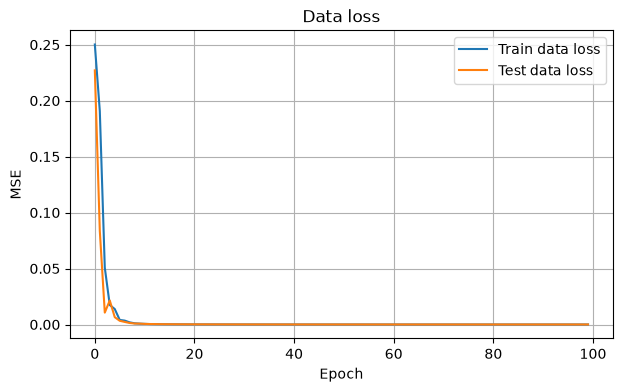

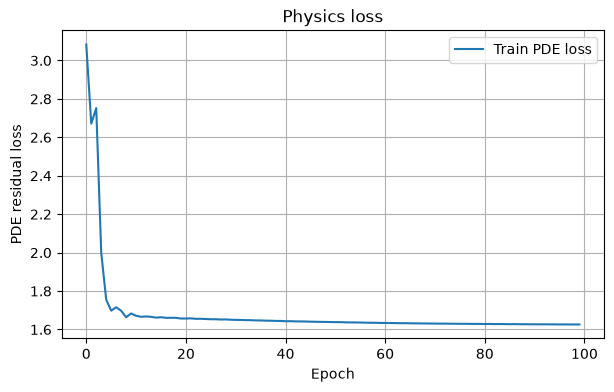

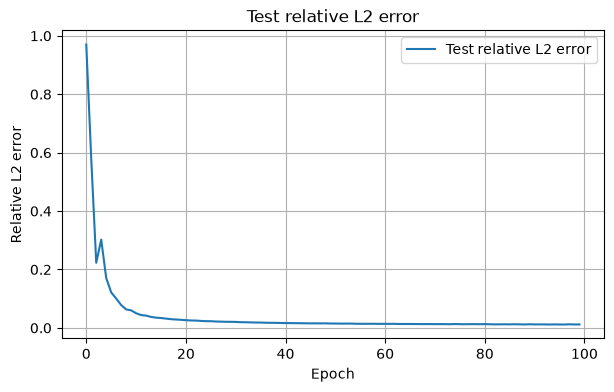

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(train_data_history, label="Train data loss")
plt.plot(test_data_history, label="Test data loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Data loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(train_pde_history, label="Train PDE loss")
plt.xlabel("Epoch")
plt.ylabel("PDE residual loss")
plt.title("Physics loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(test_rel_l2_history, label="Test relative L2 error")
plt.xlabel("Epoch")
plt.ylabel("Relative L2 error")
plt.title("Test relative L2 error")
plt.legend()
plt.grid(True)
plt.show()

## 10. Visualize PINO prediction

For a test initial condition, we compare:

$$
\omega_{\mathrm{true}}(t,x,y)
\quad\text{and}\quad
\omega_\theta(t,x,y).
$$

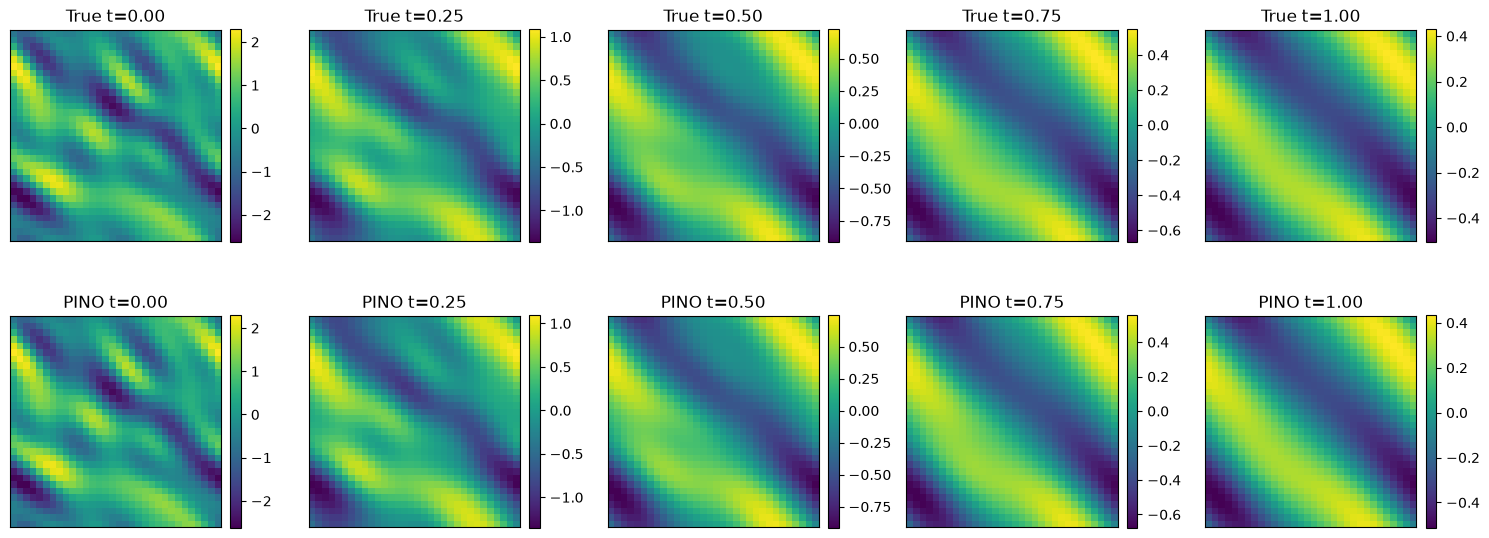

In [13]:
def plot_pino_trajectory(model, test_x, test_y, sample_id=0, name="PINO"):
    model.eval()

    with torch.no_grad():
        pred_future = model(test_x[sample_id:sample_id + 1])

    # Full true trajectory: concatenate input and target
    true_full = torch.cat(
        [test_x[sample_id:sample_id + 1], test_y[sample_id:sample_id + 1]],
        dim=-1
    )

    pred_full = torch.cat(
        [test_x[sample_id:sample_id + 1], pred_future],
        dim=-1
    )

    true_full = true_full[0].detach().cpu()  # (nx, ny, n_frames)
    pred_full = pred_full[0].detach().cpu()

    plt.figure(figsize=(3 * n_frames, 6))

    for j in range(n_frames):
        # True solution
        plt.subplot(2, n_frames, j + 1)
        plt.imshow(true_full[:, :, j], origin="lower")
        plt.title(f"True t={j * dt_save:.2f}")
        plt.xticks([])
        plt.yticks([])
        plt.colorbar(fraction=0.046, pad=0.04)

        # Prediction
        plt.subplot(2, n_frames, n_frames + j + 1)
        plt.imshow(pred_full[:, :, j], origin="lower")
        plt.title(f"{name} t={j * dt_save:.2f}")
        plt.xticks([])
        plt.yticks([])
        plt.colorbar(fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


plot_pino_trajectory(
    pino,
    w0_test,
    y_test,
    sample_id=0,
    name="PINO"
)

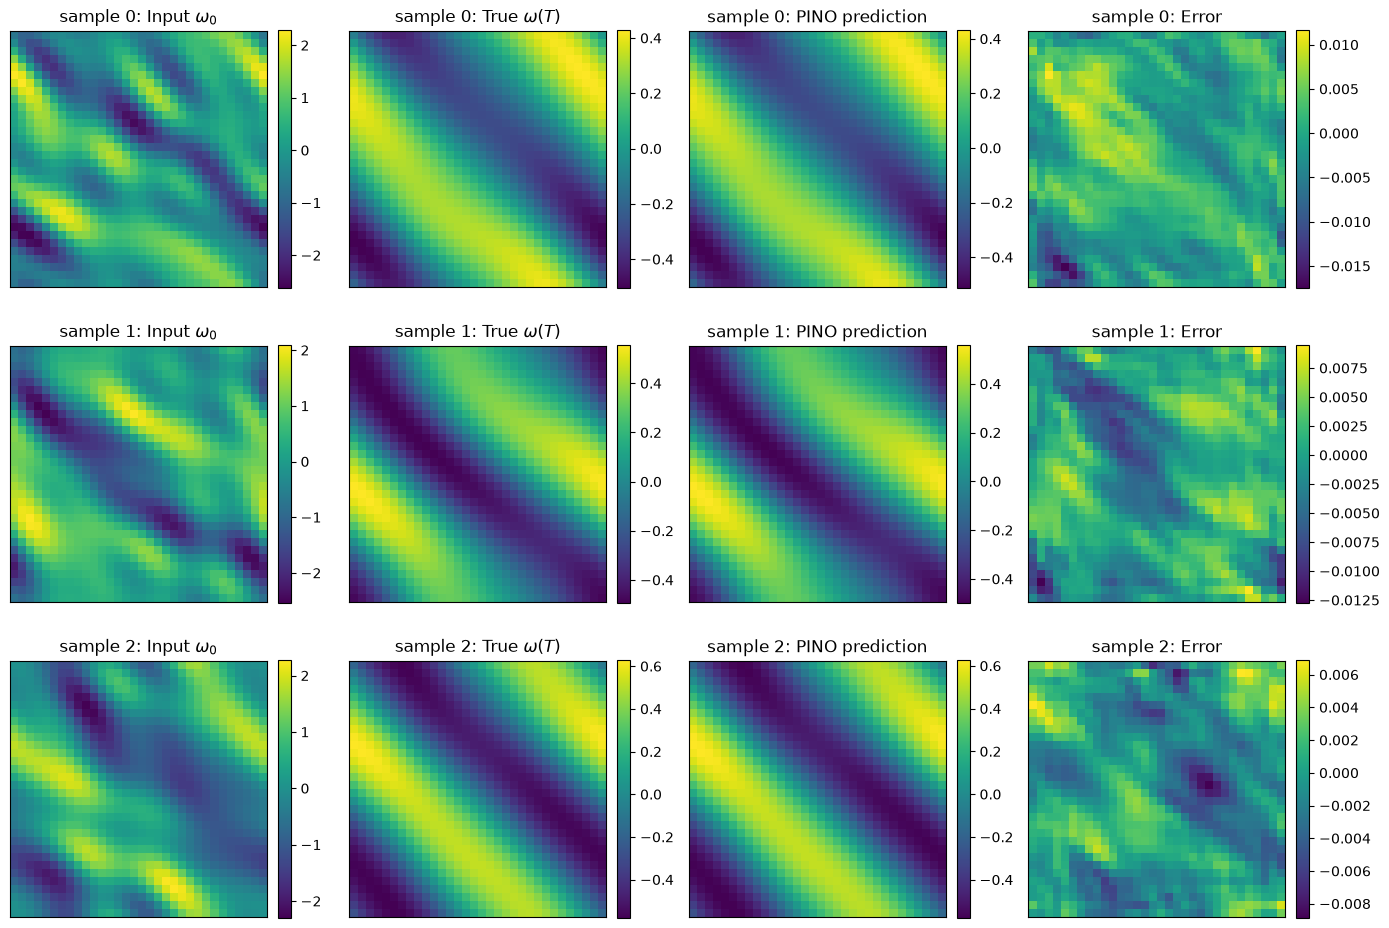

In [14]:
def plot_multiple_pino_results(model, test_x, test_y, sample_ids=[0, 1, 2], name="PINO"):
    """
    Show that different initial conditions produce different final-time solutions.
    """
    model.eval()

    n_samples = len(sample_ids)

    plt.figure(figsize=(14, 3.2 * n_samples))

    for row, sample_id in enumerate(sample_ids):
        with torch.no_grad():
            pred_future = model(test_x[sample_id:sample_id + 1])

        w0 = test_x[sample_id, :, :, 0].detach().cpu()
        true_final = test_y[sample_id, :, :, -1].detach().cpu()
        pred_final = pred_future[0, :, :, -1].detach().cpu()
        error = pred_final - true_final

        images = [w0, true_final, pred_final, error]
        titles = [
            r"Input $\omega_0$",
            r"True $\omega(T)$",
            rf"{name} prediction",
            "Error"
        ]

        for col in range(4):
            plt.subplot(n_samples, 4, 4 * row + col + 1)
            plt.imshow(images[col], origin="lower")
            plt.colorbar(fraction=0.046, pad=0.04)
            plt.title(f"sample {sample_id}: {titles[col]}")
            plt.xticks([])
            plt.yticks([])

    plt.tight_layout()
    plt.show()


plot_multiple_pino_results(
    pino,
    w0_test,
    y_test,
    sample_ids=[0, 1, 2],
    name="PINO"
)